# Triage baseline — what the LLM has to beat

An LLM that classifies support tickets is only interesting if it beats the
cheap thing. This notebook builds the cheap thing: **TF-IDF + logistic
regression**, trained on the same labels the LLM is scored against.

Two numbers matter for each target:

- **Majority-class accuracy** — always predict the most common label. A model
  below this has learned nothing.
- **Baseline accuracy** — this classifier. The LLM has to beat *this* to justify
  costing ~200× more and taking ~10s instead of ~10ms.

The split is made on **deduplicated subjects**, because
[notebook 01](01-dataset-exploration.ipynb) found 9,388 repeated subjects —
generic openers like "Customer Support Inquiry" recur hundreds of times, and a
naive split puts identical text on both sides of it.

In [1]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 10,
})

DATA = "../customer_support"
LABELS = ["type", "queue", "priority"]

frames = [pd.read_csv(p) for p in sorted(glob.glob(f"{DATA}/*.csv"))]
labelled = pd.concat(
    [df for df in frames if all(c in df.columns for c in LABELS)], ignore_index=True
)
en = labelled[labelled["language"] == "en"].dropna(subset=["subject", "body"]).copy()
en["text"] = en["subject"].str.strip() + "\n\n" + en["body"].str.strip()
print(f"English labelled tickets: {len(en):,}")

English labelled tickets: 25,840


## The split has to respect duplicate subjects

Grouping by subject and assigning whole groups to one side keeps identical text
from appearing in both. The cost is a slightly uneven split; the benefit is a
score that means something.

In [2]:
rng = np.random.default_rng(42)

subjects = en["subject"].str.strip().str.lower().unique()
rng.shuffle(subjects)
test_subjects = set(subjects[: int(len(subjects) * 0.25)])

is_test = en["subject"].str.strip().str.lower().isin(test_subjects)
train, test = en[~is_test], en[is_test]

overlap = set(train["subject"].str.strip().str.lower()) & set(
    test["subject"].str.strip().str.lower()
)
print(f"train {len(train):,} | test {len(test):,}")
print(f"subjects appearing in both sets: {len(overlap)}   <- must be 0")

train 19,310 | test 6,530
subjects appearing in both sets: 0   <- must be 0


### What a naive split would have scored

Worth measuring rather than asserting: the same model, split at random, to see
how much the leakage inflates the number.

In [3]:
def fit_score(train_df, test_df, target):
    model = make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), max_features=60_000),
        LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced"),
    )
    model.fit(train_df["text"], train_df[target])
    predicted = model.predict(test_df["text"])
    return model, predicted, accuracy_score(test_df[target], predicted)

naive = en.sample(frac=1.0, random_state=42)
cut = int(len(naive) * 0.75)
naive_train, naive_test = naive.iloc[:cut], naive.iloc[cut:]

rows = []
for target in LABELS:
    _, _, grouped_acc = fit_score(train, test, target)
    _, _, naive_acc = fit_score(naive_train, naive_test, target)
    rows.append({
        "target": target,
        "grouped split": f"{grouped_acc:.1%}",
        "naive split": f"{naive_acc:.1%}",
        "inflation": f"{(naive_acc - grouped_acc) * 100:+.1f} pts",
    })
pd.DataFrame(rows).set_index("target")

,grouped split,naive split,inflation
target,,,
type,84.0%,87.9%,+3.9 pts
queue,57.3%,64.4%,+7.2 pts
priority,61.8%,71.2%,+9.4 pts


The naive split scores higher on every target, and that gap is pure leakage —
the model recognising subjects it has already seen. Every number below uses the
grouped split.

## The baseline, against the floor

In [4]:
results = {}
summary = []

for target in LABELS:
    model, predicted, acc = fit_score(train, test, target)
    majority = test[target].value_counts(normalize=True).max()
    macro_f1 = f1_score(test[target], predicted, average="macro")

    results[target] = {"model": model, "predicted": predicted, "truth": test[target]}
    summary.append({
        "target": target,
        "classes": test[target].nunique(),
        "majority-class": f"{majority:.1%}",
        "baseline": f"{acc:.1%}",
        "lift": f"{(acc - majority) * 100:+.1f} pts",
        "macro F1": f"{macro_f1:.3f}",
    })

baseline_table = pd.DataFrame(summary).set_index("target")
baseline_table

,classes,majority-class,baseline,lift,macro F1
target,,,,,
type,4,39.2%,84.0%,+44.9 pts,0.848
queue,10,29.2%,57.3%,+28.1 pts,0.570
priority,3,41.2%,61.8%,+20.6 pts,0.604


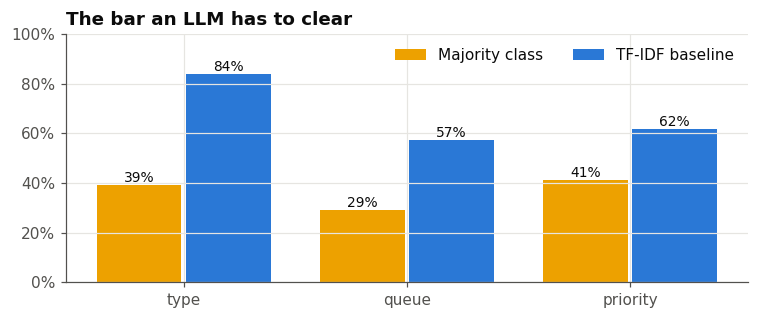

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(LABELS))
majority_vals = [test[t].value_counts(normalize=True).max() for t in LABELS]
baseline_vals = [accuracy_score(results[t]["truth"], results[t]["predicted"]) for t in LABELS]

ax.bar(x - 0.2, majority_vals, 0.38, label="Majority class", color=C[3])
ax.bar(x + 0.2, baseline_vals, 0.38, label="TF-IDF baseline", color=C[0])
for i, (m, b) in enumerate(zip(majority_vals, baseline_vals)):
    ax.text(i - 0.2, m, f"{m:.0%}", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.2, b, f"{b:.0%}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, LABELS)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("The bar an LLM has to clear", loc="left", fontweight="semibold")
ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

## Priority is the one that matters, and the hardest

The product acts on priority: it drives SLA and escalation. Accuracy hides how
badly a model does on `high` — the class whose misses actually cost money.

In [6]:
print(classification_report(
    results["priority"]["truth"], results["priority"]["predicted"], digits=3
))

              precision    recall  f1-score   support

        high      0.651     0.654     0.652      2514
         low      0.525     0.531     0.528      1327
      medium      0.634     0.628     0.631      2689

    accuracy                          0.618      6530
   macro avg      0.603     0.604     0.604      6530
weighted avg      0.618     0.618     0.618      6530



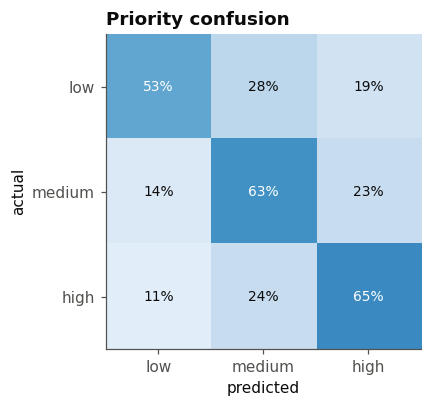

recall on 'high': 65.4%


In [7]:
truth = results["priority"]["truth"]
predicted = results["priority"]["predicted"]
order = ["low", "medium", "high"]
cm = confusion_matrix(truth, predicted, labels=order, normalize="true")

fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), order); ax.set_yticks(range(3), order)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else INK, fontsize=9)
ax.set_title("Priority confusion", loc="left", fontweight="semibold")
ax.grid(False)
plt.tight_layout(); plt.show()

high_recall = cm[order.index("high"), order.index("high")]
print(f"recall on 'high': {high_recall:.1%}")

## What this establishes

The baseline is cheap: it trains in seconds, predicts in about a millisecond,
and costs nothing to run. Any LLM has to be measured against these numbers
rather than against zero.

The interesting comparison is not accuracy alone. It is accuracy **per unit of
cost and latency** — and specifically recall on `high` priority, since a missed
urgent ticket is the failure that actually hurts a support team.

In [8]:
import json, pathlib

held_out = test.sample(min(300, len(test)), random_state=42)[
    ["subject", "body", "type", "queue", "priority"]
]

out = pathlib.Path("../apps/ai-service/app/eval/data")
out.mkdir(parents=True, exist_ok=True)
held_out.to_json(out / "heldout.jsonl", orient="records", lines=True)

# Both models must be scored on identical rows. Comparing a baseline measured
# on thousands of examples against an LLM measured on a few hundred different
# ones would be meaningless, however impressive the numbers looked.
baseline_scores = {
    target: {
        "accuracy": float(accuracy_score(results[target]["truth"], results[target]["predicted"])),
        "macro_f1": float(f1_score(results[target]["truth"], results[target]["predicted"], average="macro")),
        "majority_class": float(test[target].value_counts(normalize=True).max()),
        "n_test": int(len(test)),
    }
    for target in LABELS
}
(out / "baseline_scores.json").write_text(json.dumps(baseline_scores, indent=2))

print(f"wrote {len(held_out)} held-out rows for the LLM to be scored on")
print(json.dumps(baseline_scores, indent=2))

wrote 300 held-out rows for the LLM to be scored on
{
  "type": {
    "accuracy": 0.8404287901990811,
    "macro_f1": 0.8480281060123083,
    "majority_class": 0.3917304747320061,
    "n_test": 6530
  },
  "queue": {
    "accuracy": 0.5727411944869831,
    "macro_f1": 0.5700720309951058,
    "majority_class": 0.2915773353751914,
    "n_test": 6530
  },
  "priority": {
    "accuracy": 0.6182235834609494,
    "macro_f1": 0.6038063336472327,
    "majority_class": 0.411791730474732,
    "n_test": 6530
  }
}


The held-out sample and the baseline scores are written to
`apps/ai-service/app/eval/data/`, so the LLM evaluation scores **the same rows**
this baseline was measured on.